# NYC Citibike Demand Analysis: Member vs Casual

In [2]:
library(arrow)
library(dplyr)
library(ggplot2)
library(tidyr)
library(reshape2)
library(car)
library(bsts)
library(ggplot2)

# Data

## Dataset Overview

In [3]:
bucket <- "citibike-pipeline-william-842549706992-us-east-1-an"

ds <- open_dataset(
  s3_bucket(bucket, region = "us-east-1")$path("processed"),
  format = "csv"
)
citybike.data <- ds |> collect()

glimpse(citybike.data)

Rows: 1,065
Columns: 19
$ date          <date> 2022-01-01, 2022-01-02, 2022-01-03, 2022-01-04, 2022-01…
$ total_rides   <int> 592, 1248, 832, 934, 914, 1297, 459, 713, 636, 859, 683,…
$ member_count  <int> 322, 730, 643, 725, 686, 989, 353, 504, 433, 658, 520, 8…
$ casual_count  <int> 270, 518, 189, 209, 228, 308, 106, 209, 203, 201, 163, 2…
$ temp_max      <dbl> 12.5, 13.5, 2.5, 0.9, 7.4, 4.2, 0.7, -1.9, 4.0, 3.8, -3.…
$ temp_min      <dbl> 9.7, 2.7, -3.9, -7.9, -1.6, 0.2, -3.7, -6.5, -3.8, -2.7,…
$ atemp_mean    <dbl> 10.2, 8.4, -7.0, -8.0, -0.4, -2.4, -6.9, -9.7, -3.5, -6.…
$ precipitation <dbl> 14.0, 4.0, 0.0, 0.0, 4.1, 0.0, 11.9, 0.0, 2.9, 0.0, 0.0,…
$ windspeed_max <dbl> 13.7, 24.0, 29.5, 23.2, 14.0, 23.8, 30.4, 29.3, 25.1, 26…
$ weathercode   <int> 63, 63, 3, 2, 63, 3, 75, 0, 53, 3, 3, 3, 3, 3, 3, 73, 65…
$ humidity_mean <int> 96, 88, 56, 54, 85, 62, 72, 48, 73, 54, 42, 53, 66, 71, …
$ yr            <int> 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 20…
$ mnth          

In [4]:
summary(citybike.data)

      date             total_rides    member_count   casual_count   
 Min.   :2022-01-01   Min.   : 111   Min.   :  79   Min.   :  32.0  
 1st Qu.:2022-10-25   1st Qu.:1922   1st Qu.:1428   1st Qu.: 375.0  
 Median :2023-07-18   Median :2772   Median :1972   Median : 675.0  
 Mean   :2023-07-12   Mean   :2656   Mean   :1928   Mean   : 727.8  
 3rd Qu.:2024-04-09   3rd Qu.:3535   3rd Qu.:2460   3rd Qu.: 973.0  
 Max.   :2024-12-31   Max.   :4531   Max.   :3463   Max.   :2354.0  
    temp_max        temp_min         atemp_mean     precipitation    
 Min.   :-9.80   Min.   :-15.800   Min.   :-19.90   Min.   :  0.000  
 1st Qu.:10.10   1st Qu.:  2.200   1st Qu.:  1.90   1st Qu.:  0.000  
 Median :18.00   Median :  8.700   Median : 10.70   Median :  0.000  
 Mean   :17.76   Mean   :  9.117   Mean   : 11.31   Mean   :  3.211  
 3rd Qu.:26.10   3rd Qu.: 16.600   3rd Qu.: 21.00   3rd Qu.:  0.400  
 Max.   :36.20   Max.   : 26.400   Max.   : 34.70   Max.   :139.400  
 windspeed_max    weatherco

In [5]:
table(citybike.data$weathercode)


  0   1   2   3  45  51  53  55  61  63  65  66  71  73  75  80  81  82  95 
 51  43  59 566  41  41  26  11  42  72  51   1   7  21  10   3   2   5  13 

In [6]:
citybike.data <- citybike.data |>
  select(-yr, -mnth) |>
  mutate(
    season     = factor(season, levels = 1:4, labels = c("Winter", "Spring", "Summer", "Fall")),
    weekday    = factor(weekday, levels = 0:6),
    workingday = factor(workingday, levels = c(0, 1)),
    holiday    = factor(holiday, levels = c(0, 1)),
    weather_cat = case_when(
      weathercode %in% c(0, 1, 2)                ~ 1L,
      weathercode %in% c(3, 45)                  ~ 2L,
      weathercode %in% c(51, 53, 55, 61)         ~ 3L,
      weathercode %in% c(63, 65, 66, 80, 81, 82) ~ 4L,
      weathercode %in% c(71, 73, 75)             ~ 5L,
      weathercode == 95                           ~ 6L
    ) |> factor(levels = 1:6, labels = c("Clear", "Cloudy", "Light Rain", "Rain", "Snow", "Storm"))
  ) |>
  select(-weathercode)

In [7]:
summary(citybike.data)

      date             total_rides    member_count   casual_count   
 Min.   :2022-01-01   Min.   : 111   Min.   :  79   Min.   :  32.0  
 1st Qu.:2022-10-25   1st Qu.:1922   1st Qu.:1428   1st Qu.: 375.0  
 Median :2023-07-18   Median :2772   Median :1972   Median : 675.0  
 Mean   :2023-07-12   Mean   :2656   Mean   :1928   Mean   : 727.8  
 3rd Qu.:2024-04-09   3rd Qu.:3535   3rd Qu.:2460   3rd Qu.: 973.0  
 Max.   :2024-12-31   Max.   :4531   Max.   :3463   Max.   :2354.0  
                                                                    
    temp_max        temp_min         atemp_mean     precipitation    
 Min.   :-9.80   Min.   :-15.800   Min.   :-19.90   Min.   :  0.000  
 1st Qu.:10.10   1st Qu.:  2.200   1st Qu.:  1.90   1st Qu.:  0.000  
 Median :18.00   Median :  8.700   Median : 10.70   Median :  0.000  
 Mean   :17.76   Mean   :  9.117   Mean   : 11.31   Mean   :  3.211  
 3rd Qu.:26.10   3rd Qu.: 16.600   3rd Qu.: 21.00   3rd Qu.:  0.400  
 Max.   :36.20   Max.   : 26

In [8]:
table(citybike.data$weather_cat)


     Clear     Cloudy Light Rain       Rain       Snow      Storm 
       153        607        120        134         38         13 

In [9]:
citybike.na <- citybike.data |> 
  summarise(
    Total_Observations = n(),
    Missing_Values = sum(is.na(across(everything())))
  ) |>
  as.data.frame() 

print(citybike.na, row.names = FALSE)

 Total_Observations Missing_Values
               1065              0


# Exploratory Data Analysis

## Feature Distribution

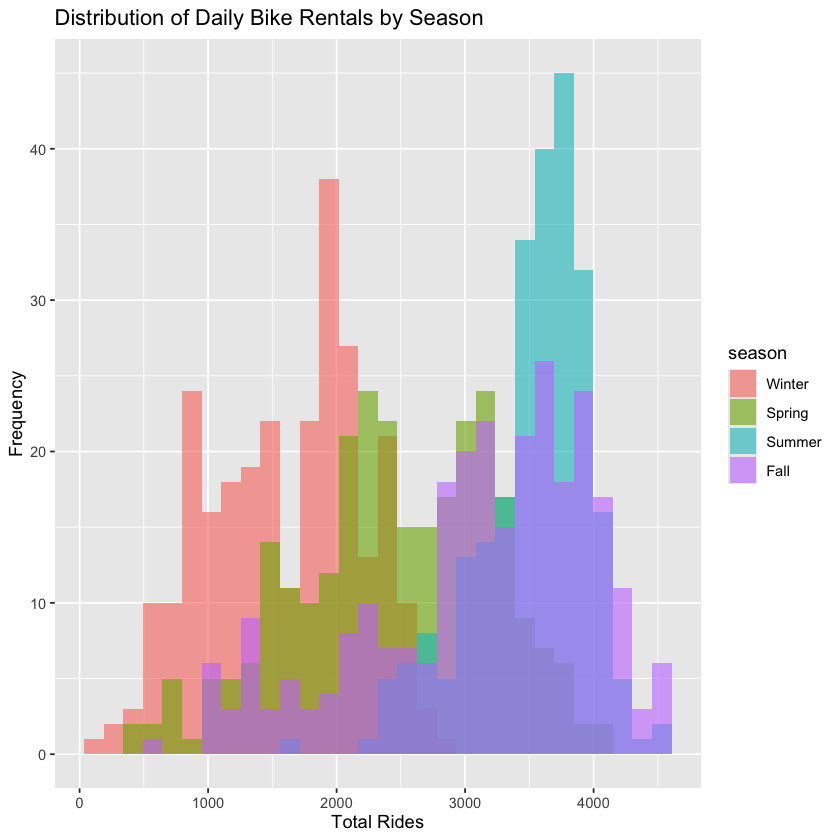

In [10]:
ggplot(citybike.data, aes(x = total_rides, fill = season)) +
  geom_histogram(bins = 30, alpha = 0.6, position = "identity") +
  labs(title = "Distribution of Daily Bike Rentals by Season",
       x = "Total Rides", y = "Frequency")

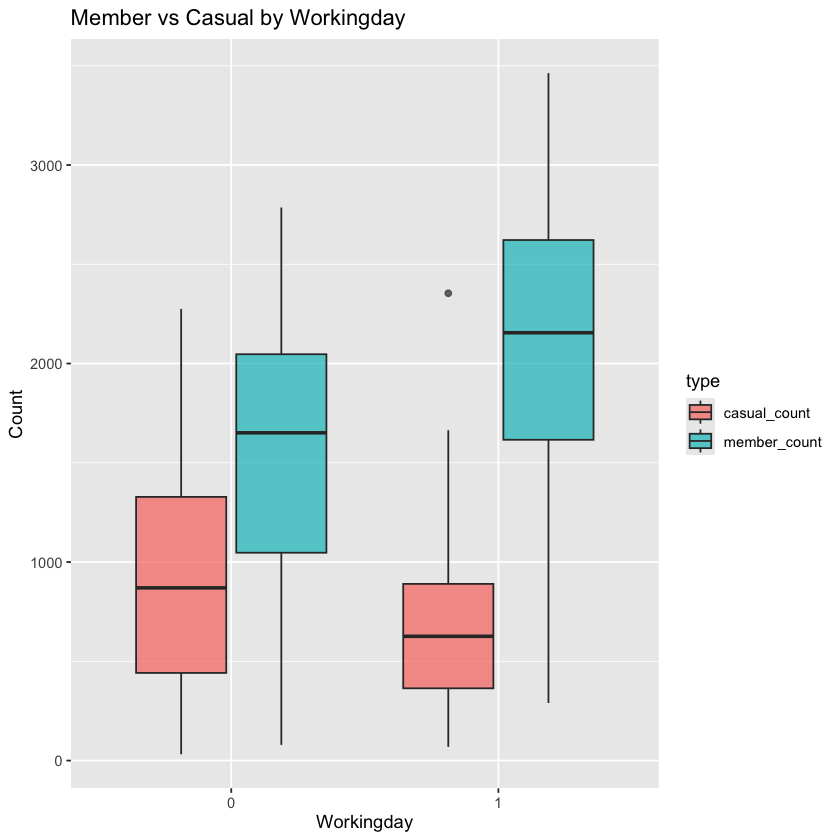

In [11]:
citybike.data |>
  pivot_longer(cols = c(member_count, casual_count),
               names_to = "type", values_to = "count") |>
  ggplot(aes(x = workingday, y = count, fill = type)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Member vs Casual by Workingday",
       x = "Workingday", y = "Count")

`geom_smooth()` using formula = 'y ~ x'


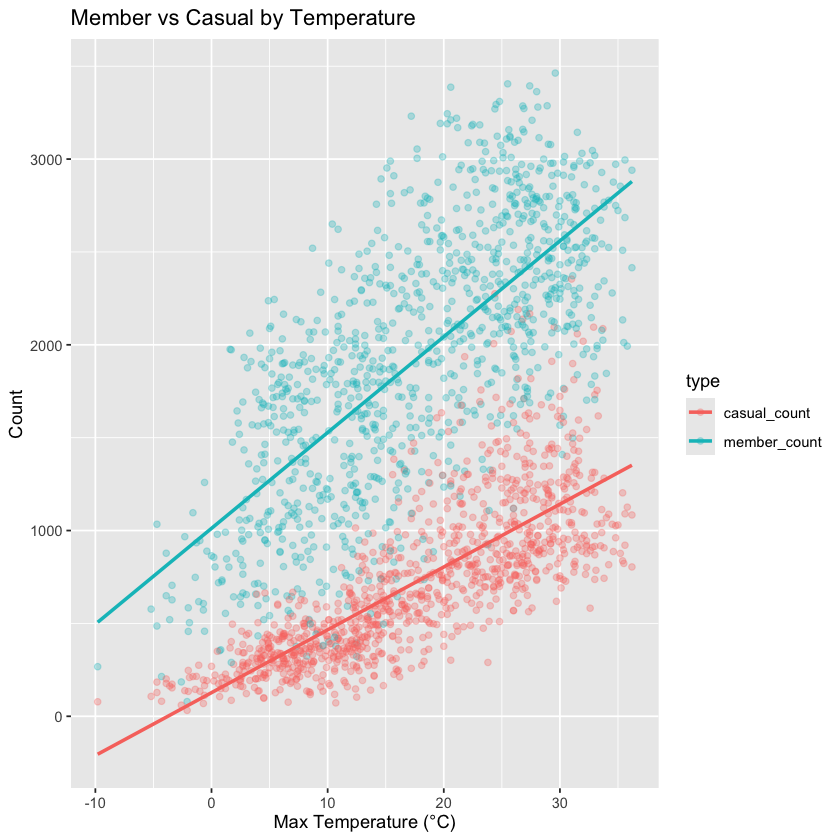

In [12]:
citybike.data |>
  pivot_longer(cols = c(member_count, casual_count),
               names_to = "type", values_to = "count") |>
  ggplot(aes(x = temp_max, y = count, color = type)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Member vs Casual by Temperature",
       x = "Max Temperature (°C)", y = "Count")

`geom_smooth()` using formula = 'y ~ x'


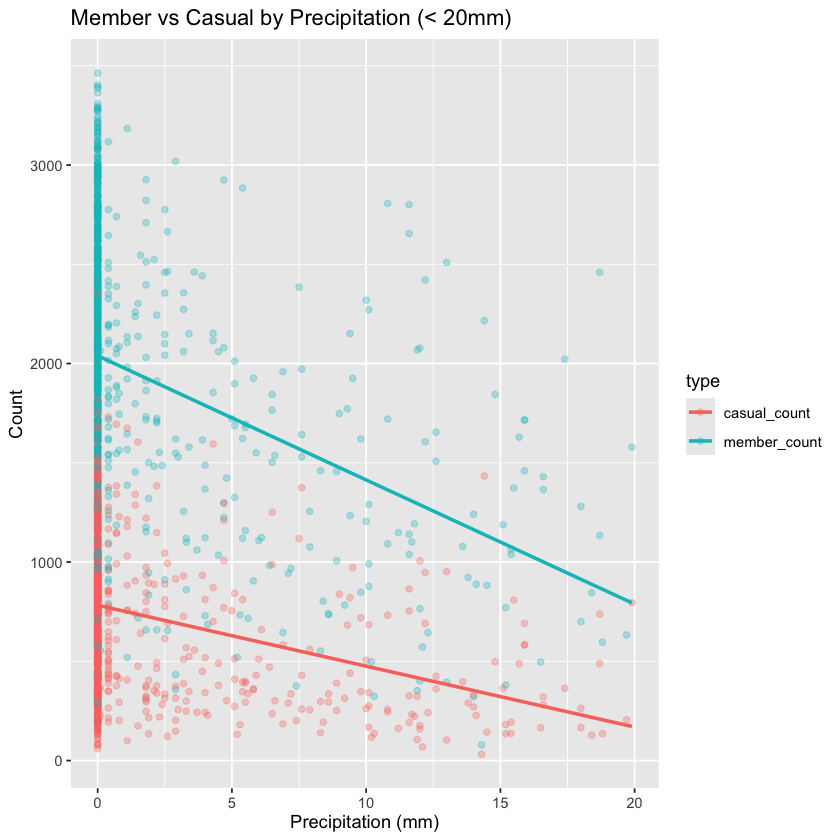

In [13]:
citybike.data |>
  filter(precipitation < 20) |>
  pivot_longer(cols = c(member_count, casual_count),
               names_to = "type", values_to = "count") |>
  ggplot(aes(x = precipitation, y = count, color = type)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Member vs Casual by Precipitation (< 20mm)",
       x = "Precipitation (mm)", y = "Count")

`geom_smooth()` using formula = 'y ~ x'


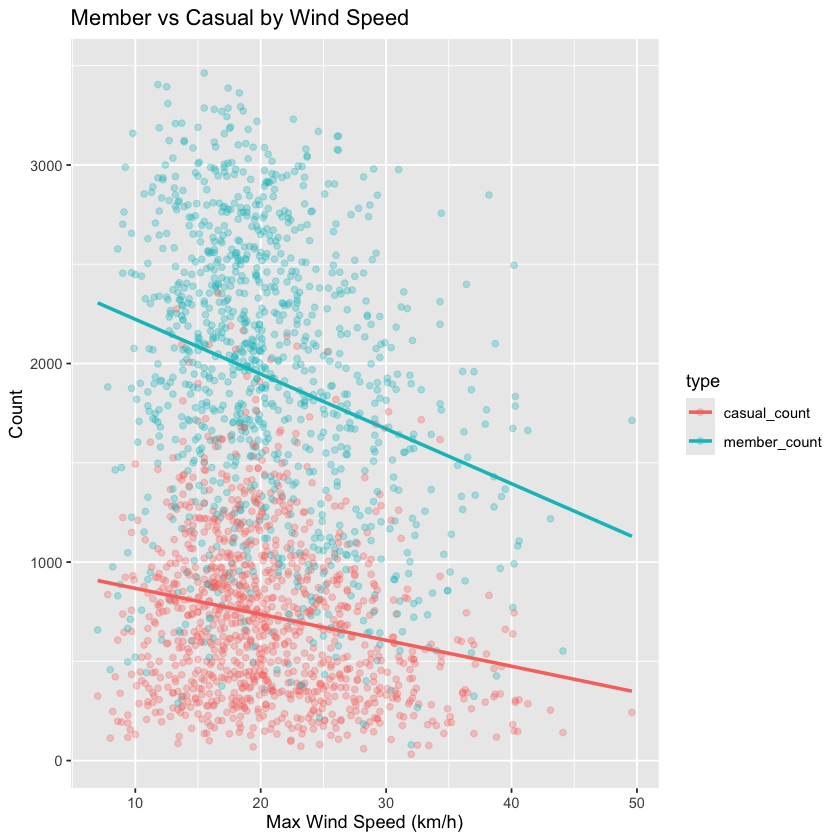

In [14]:
citybike.data |>
  pivot_longer(cols = c(member_count, casual_count),
               names_to = "type", values_to = "count") |>
  ggplot(aes(x = windspeed_max, y = count, color = type)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Member vs Casual by Wind Speed",
       x = "Max Wind Speed (km/h)", y = "Count")

## Feature Correlation

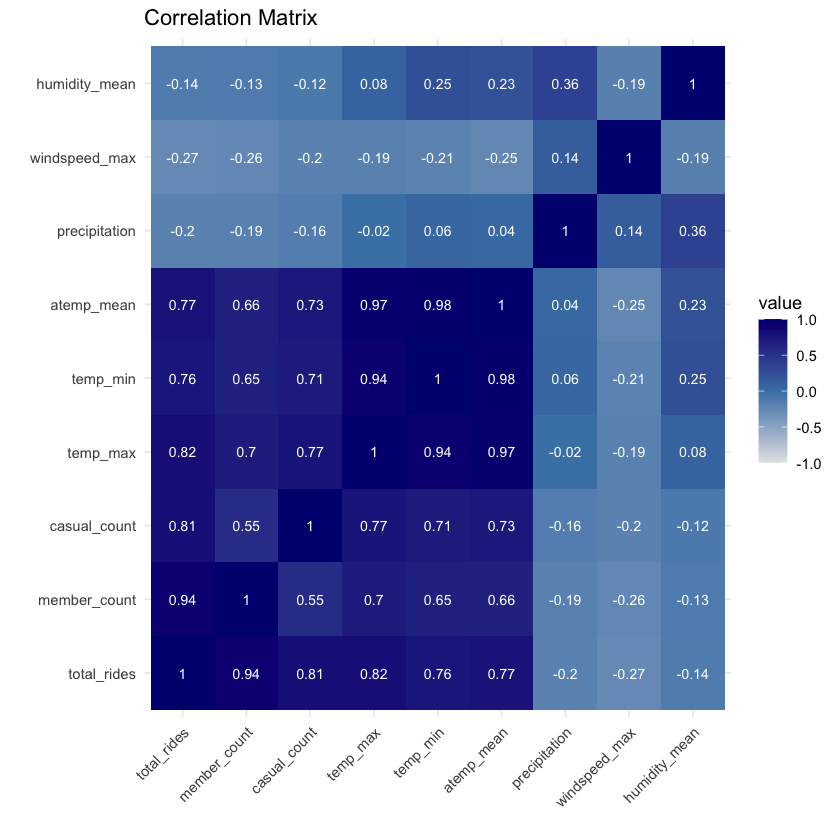

In [15]:
numeric.features <- c("total_rides", "member_count", "casual_count",
                      "temp_max", "temp_min", "atemp_mean",
                      "precipitation", "windspeed_max", "humidity_mean")

cor.matrix <- cor(citybike.data[, numeric.features], use = "complete.obs")
cor.melted <- melt(cor.matrix)

ggplot(cor.melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = round(value, 2)), size = 3, color = "white") +
  scale_fill_gradient2(low = "grey90", mid = "steelblue", high = "navy",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Correlation Matrix", x = "", y = "") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Multicollinearity Check (VIF)

In [16]:
compute_vif <- function(data) {
  lm.proxy <- lm(total_rides ~ temp_max + precipitation + 
                   windspeed_max + humidity_mean + 
                   season + workingday + weather_cat, data = data)
  vif.result <- vif(lm.proxy)
  print(vif.result)
  invisible(vif.result)
}

compute_vif(citybike.data)

                  GVIF Df GVIF^(1/(2*Df))
temp_max      3.075775  1        1.753789
precipitation 1.641704  1        1.281290
windspeed_max 1.227065  1        1.107730
humidity_mean 1.786893  1        1.336747
season        3.035496  3        1.203294
workingday    1.008734  1        1.004358
weather_cat   2.694342  5        1.104194


# Methodology

## Model Specification

In [17]:
run_bsts <- function(data, target, formula, niter = 1000, seed = 42) {
  set.seed(seed)
  ss <- AddLocalLinearTrend(list(), data[[target]])
  ss <- AddSeasonal(ss, data[[target]], nseasons = 7)
  
  model <- bsts(formula,
                state.specification = ss,
                data = data,
                niter = niter)
  
  return(model)
}

In [18]:
run_ols <- function(data, formula) {
  model <- lm(formula, data = data)
  return(model)
}

## Baseline

### Member Baseline

In [19]:
member.baseline <- run_bsts(
  data    = citybike.data,
  target  = "member_count",
  formula = member_count ~ temp_max + precipitation + 
              windspeed_max + humidity_mean + 
              season + workingday + weather_cat
)

=-=-=-=-= Iteration 0 Wed Jun 24 20:47:27 2026 =-=-=-=-=
=-=-=-=-= Iteration 100 Wed Jun 24 20:47:28 2026 =-=-=-=-=
=-=-=-=-= Iteration 200 Wed Jun 24 20:47:28 2026 =-=-=-=-=
=-=-=-=-= Iteration 300 Wed Jun 24 20:47:29 2026 =-=-=-=-=
=-=-=-=-= Iteration 400 Wed Jun 24 20:47:30 2026 =-=-=-=-=
=-=-=-=-= Iteration 500 Wed Jun 24 20:47:30 2026 =-=-=-=-=
=-=-=-=-= Iteration 600 Wed Jun 24 20:47:31 2026 =-=-=-=-=
=-=-=-=-= Iteration 700 Wed Jun 24 20:47:31 2026 =-=-=-=-=
=-=-=-=-= Iteration 800 Wed Jun 24 20:47:32 2026 =-=-=-=-=
=-=-=-=-= Iteration 900 Wed Jun 24 20:47:32 2026 =-=-=-=-=


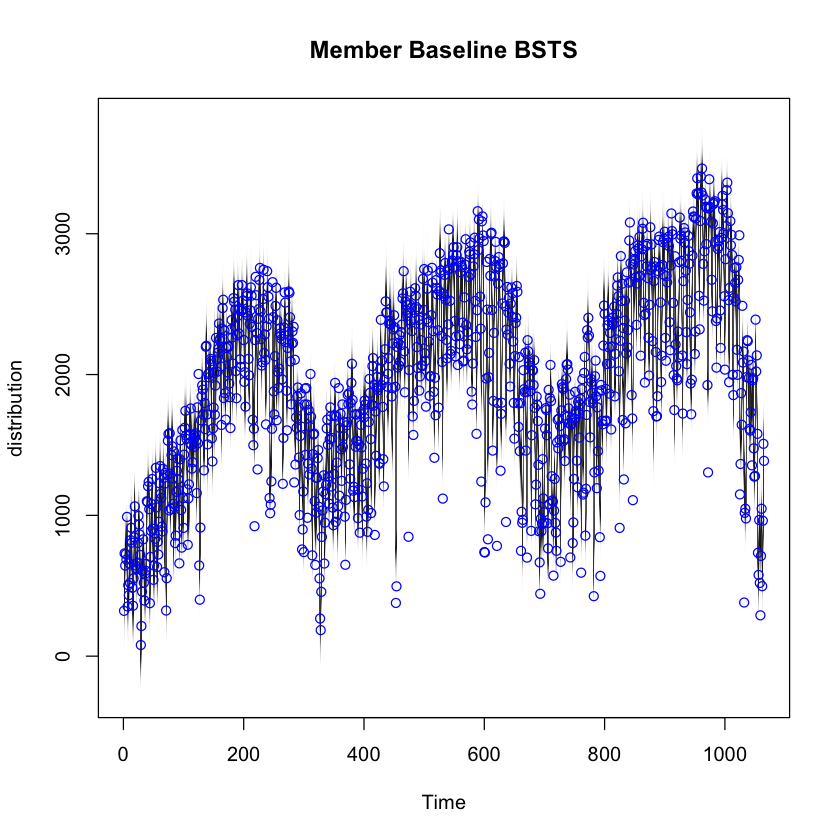

In [20]:
plot(member.baseline, main = "Member Baseline BSTS")

In [21]:
summary(member.baseline)

$residual.sd
[1] 185.1673

$prediction.sd
[1] 265.0301

$rsquare
[1] 0.9316156

$relative.gof
[1] 0.6747189

$size
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  6.000   7.000   7.000   7.114   7.000   8.000 

$coefficients
                              mean         sd    mean.inc     sd.inc
weather_catSnow       -226.3000581 40.2105689 -226.300058 40.2105689
weather_catRain       -252.2174628 28.5491343 -252.217463 28.5491343
workingday1            470.4448574 41.6368220  470.444857 41.6368220
humidity_mean           -6.0730429  0.5518781   -6.073043  0.5518781
windspeed_max           -6.0648086  1.4367649   -6.064809  1.4367649
temp_max                28.9205764  1.8483342   28.920576  1.8483342
precipitation           -3.7141592  1.0176520   -3.804748  0.8453635
weather_catLight Rain   -9.3187784 27.3142705  -81.539311 25.1923045
seasonSummer             1.9698445 14.2336906  103.416836 11.2199724
seasonFall              -0.2078508  3.0120446  -43.648674  0.0000000
weather_catSt

### Casual Baseline

In [22]:
casual.baseline <- run_bsts(
  data    = citybike.data,
  target  = "casual_count",
  formula = casual_count ~ temp_max + precipitation + 
              windspeed_max + humidity_mean + 
              season + workingday + weather_cat
)

=-=-=-=-= Iteration 0 Wed Jun 24 20:47:33 2026 =-=-=-=-=
=-=-=-=-= Iteration 100 Wed Jun 24 20:47:34 2026 =-=-=-=-=
=-=-=-=-= Iteration 200 Wed Jun 24 20:47:34 2026 =-=-=-=-=
=-=-=-=-= Iteration 300 Wed Jun 24 20:47:35 2026 =-=-=-=-=
=-=-=-=-= Iteration 400 Wed Jun 24 20:47:35 2026 =-=-=-=-=
=-=-=-=-= Iteration 500 Wed Jun 24 20:47:36 2026 =-=-=-=-=
=-=-=-=-= Iteration 600 Wed Jun 24 20:47:37 2026 =-=-=-=-=
=-=-=-=-= Iteration 700 Wed Jun 24 20:47:37 2026 =-=-=-=-=
=-=-=-=-= Iteration 800 Wed Jun 24 20:47:38 2026 =-=-=-=-=
=-=-=-=-= Iteration 900 Wed Jun 24 20:47:38 2026 =-=-=-=-=


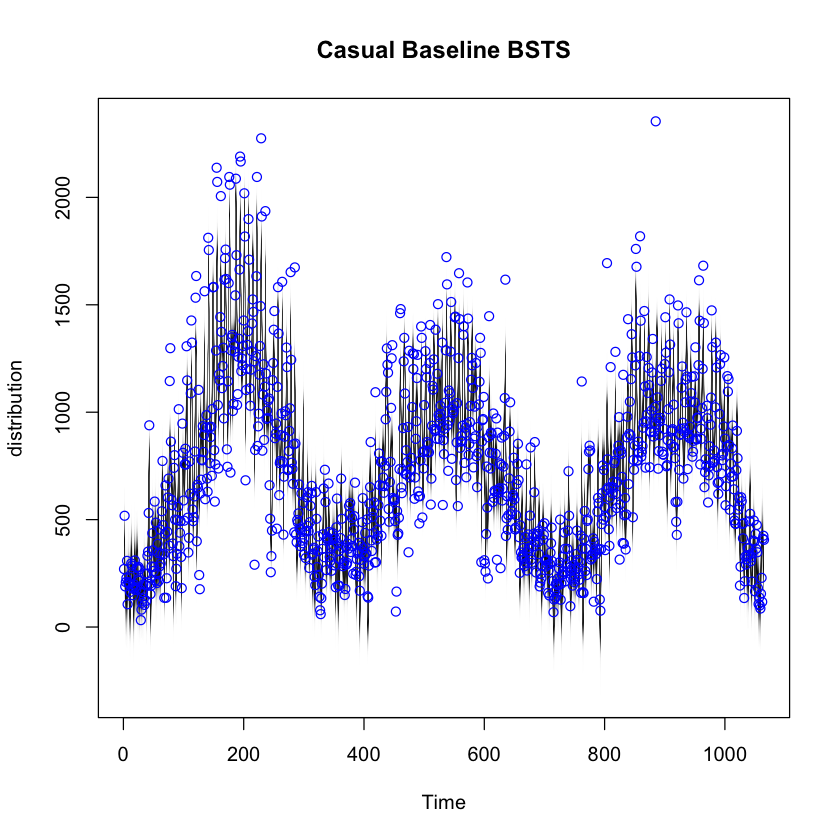

In [23]:
plot(casual.baseline, main = "Casual Baseline BSTS")

In [24]:
summary(casual.baseline)

$residual.sd
[1] 155.8309

$prediction.sd
[1] 184.478

$rsquare
[1] 0.8640797

$relative.gof
[1] 0.6405508

$size
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    6.00    6.00    5.88    6.00    7.00 

$coefficients
                               mean         sd    mean.inc     sd.inc
weather_catRain       -129.49089628 21.6859893 -129.490896 21.6859893
workingday1           -606.86145013 48.2385598 -606.861450 48.2385598
humidity_mean           -3.76995358  0.4653607   -3.769954  0.4653607
windspeed_max           -4.80273527  0.8508068   -4.802735  0.8508068
temp_max                27.54230816  1.1701721   27.542308  1.1701721
weather_catLight Rain  -68.20929619 33.3415821  -80.652884 17.5538680
weather_catStorm        -1.84967486 17.5879429 -161.846550 38.2029751
seasonSummer             0.44278620  5.0682064   38.743792 31.7750377
weather_catCloudy        0.23791929  3.2028692   41.635876 11.5278371
precipitation           -0.01232495  0.1628487   -2.156867  0.0662931
wea

## Interaction

### Member with Interaction

In [25]:
member.interaction <- run_bsts(
  data    = citybike.data,
  target  = "member_count",
  formula = member_count ~ temp_max + precipitation + 
              windspeed_max + humidity_mean + 
              season + workingday + weather_cat +
              temp_max:workingday + precipitation:workingday
)

=-=-=-=-= Iteration 0 Wed Jun 24 20:47:39 2026 =-=-=-=-=
=-=-=-=-= Iteration 100 Wed Jun 24 20:47:40 2026 =-=-=-=-=
=-=-=-=-= Iteration 200 Wed Jun 24 20:47:40 2026 =-=-=-=-=
=-=-=-=-= Iteration 300 Wed Jun 24 20:47:41 2026 =-=-=-=-=
=-=-=-=-= Iteration 400 Wed Jun 24 20:47:41 2026 =-=-=-=-=
=-=-=-=-= Iteration 500 Wed Jun 24 20:47:42 2026 =-=-=-=-=
=-=-=-=-= Iteration 600 Wed Jun 24 20:47:42 2026 =-=-=-=-=
=-=-=-=-= Iteration 700 Wed Jun 24 20:47:43 2026 =-=-=-=-=
=-=-=-=-= Iteration 800 Wed Jun 24 20:47:43 2026 =-=-=-=-=
=-=-=-=-= Iteration 900 Wed Jun 24 20:47:44 2026 =-=-=-=-=


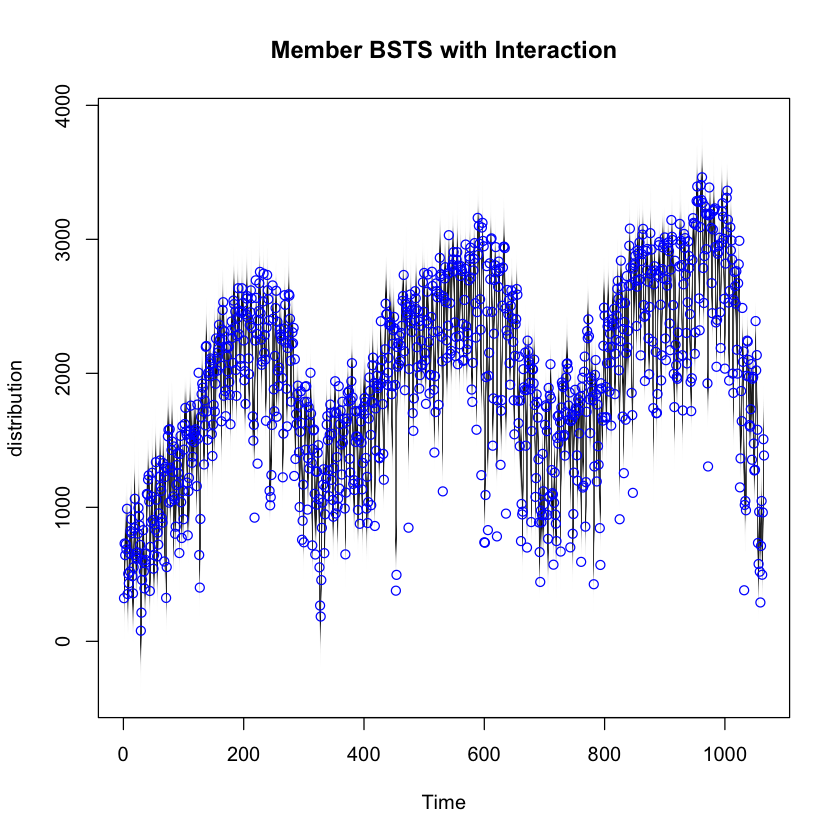

In [26]:
plot(member.interaction, main = "Member BSTS with Interaction")

In [27]:
summary(member.interaction)

$residual.sd
[1] 182.7072

$prediction.sd
[1] 263.9673

$rsquare
[1] 0.9334206

$relative.gof
[1] 0.6773261

$size
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   7.00    7.00    7.00    7.45    8.00    9.00 

$coefficients
                                   mean         sd    mean.inc     sd.inc
weather_catSnow           -239.59712277 40.4714455 -239.597123 40.4714455
weather_catRain           -260.75716404 33.7654902 -260.757164 33.7654902
workingday1                476.07006920 33.7701717  476.070069 33.7701717
humidity_mean               -5.32308279  0.7540070   -5.323083  0.7540070
windspeed_max               -5.48798956  1.3437023   -5.487990  1.3437023
temp_max                    32.03076663  1.4870760   32.030767  1.4870760
precipitation               -4.05839548  0.9241163   -4.146621  0.7109524
weather_catLight Rain      -42.16769863 49.2087669  -95.130328 20.2102315
precipitation:workingday1   -0.04229183  0.4099593   -3.975432  0.3993208
temp_max:workingday1         0.0

### Casual with Interaction

In [28]:
casual.interaction <- run_bsts(
  data    = citybike.data,
  target  = "casual_count",
  formula = casual_count ~ temp_max + precipitation + 
              windspeed_max + humidity_mean + 
              season + workingday + weather_cat +
              temp_max:workingday + precipitation:workingday
)

=-=-=-=-= Iteration 0 Wed Jun 24 20:47:45 2026 =-=-=-=-=
=-=-=-=-= Iteration 100 Wed Jun 24 20:47:45 2026 =-=-=-=-=
=-=-=-=-= Iteration 200 Wed Jun 24 20:47:46 2026 =-=-=-=-=
=-=-=-=-= Iteration 300 Wed Jun 24 20:47:47 2026 =-=-=-=-=
=-=-=-=-= Iteration 400 Wed Jun 24 20:47:47 2026 =-=-=-=-=
=-=-=-=-= Iteration 500 Wed Jun 24 20:47:48 2026 =-=-=-=-=
=-=-=-=-= Iteration 600 Wed Jun 24 20:47:48 2026 =-=-=-=-=
=-=-=-=-= Iteration 700 Wed Jun 24 20:47:49 2026 =-=-=-=-=
=-=-=-=-= Iteration 800 Wed Jun 24 20:47:49 2026 =-=-=-=-=
=-=-=-=-= Iteration 900 Wed Jun 24 20:47:50 2026 =-=-=-=-=


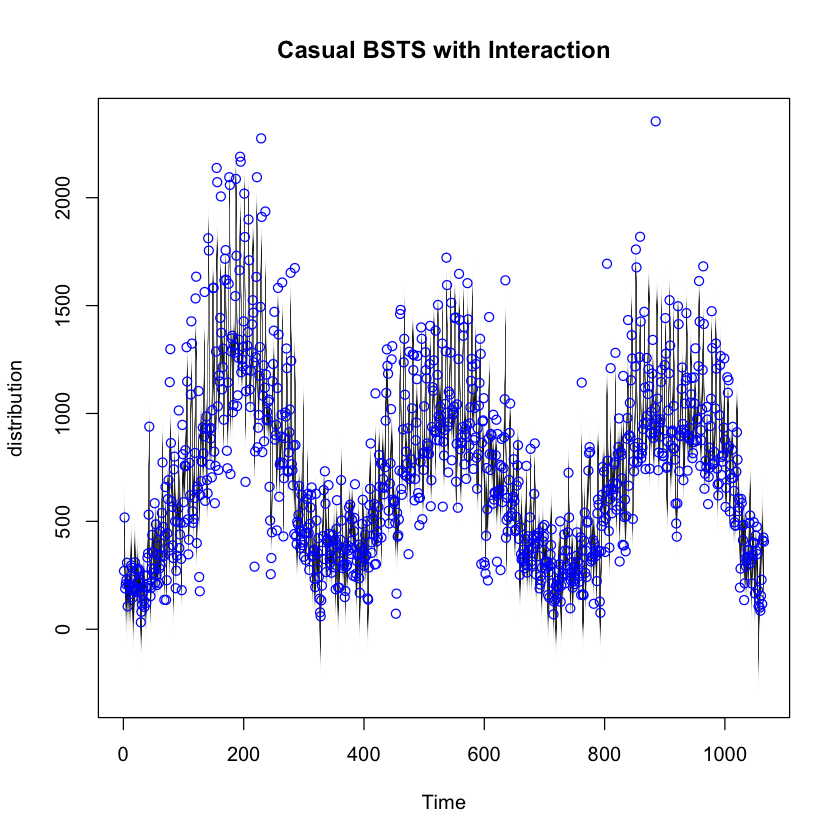

In [29]:
plot(casual.interaction, main = "Casual BSTS with Interaction")

In [30]:
summary(casual.interaction)

$residual.sd
[1] 152.2296

$prediction.sd
[1] 170.1706

$rsquare
[1] 0.8702895

$relative.gof
[1] 0.694121

$size
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.00    6.00    6.00    6.09    6.00    9.00 

$coefficients
                                   mean         sd    mean.inc     sd.inc
temp_max:workingday1       -20.37293730  1.4941482  -20.372937  1.4941482
weather_catRain           -129.73428047 19.5824280 -129.734280 19.5824280
humidity_mean               -4.02719713  0.4845074   -4.027197  0.4845074
windspeed_max               -4.06702376  0.6818783   -4.067024  0.6818783
temp_max                    41.71700693  1.2900122   41.717007  1.2900122
weather_catLight Rain      -59.06844005 34.4596381  -74.981855 17.6112001
workingday1                -21.95287966 44.5536156 -105.222423 27.0367162
weather_catStorm           -11.75223177 44.5206790 -171.953707 37.7430309
seasonSummer                 1.14515900  9.5377362   79.588551  8.6692308
weather_catCloudy            0.29

# Model Comparison

## Coefficient Comparison Across Models

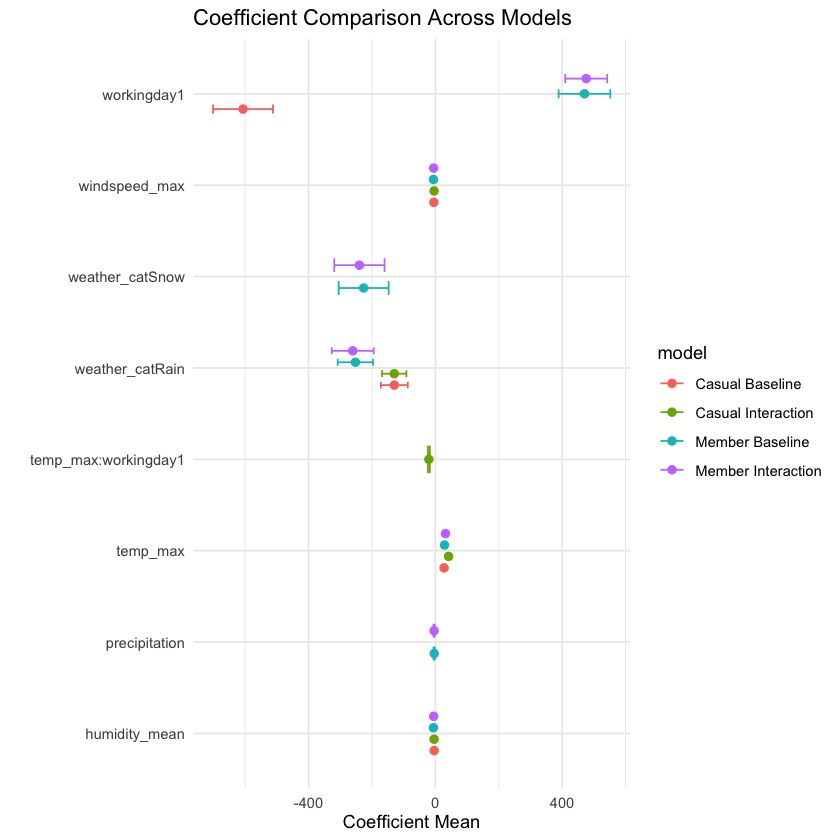

In [31]:
extract_coef <- function(model, model_name) {
  coef <- summary(model)$coefficients
  data.frame(
    term     = rownames(coef),
    mean     = coef[, "mean"],
    sd       = coef[, "sd"],
    inc.prob = coef[, "inc.prob"],
    model    = model_name
  )
}

coef.all <- rbind(
  extract_coef(member.baseline,    "Member Baseline"),
  extract_coef(casual.baseline,    "Casual Baseline"),
  extract_coef(member.interaction, "Member Interaction"),
  extract_coef(casual.interaction, "Casual Interaction")
)

coef.sig <- coef.all |> filter(inc.prob > 0.9)

ggplot(coef.sig, aes(x = term, y = mean, color = model)) +
  geom_point(position = position_dodge(0.5), size = 2) +
  geom_errorbar(aes(ymin = mean - 1.96 * sd, ymax = mean + 1.96 * sd),
                position = position_dodge(0.5), width = 0.3) +
  coord_flip() +
  labs(title = "Coefficient Comparison Across Models",
       x = "", y = "Coefficient Mean") +
  theme_minimal()

In [32]:
coef.all |>
  filter(term == "workingday1", model %in% c("Member Baseline", "Casual Baseline")) |>
  select(model, mean) |>
  mutate(mean = round(mean, 2)) |>
  summarise(
    member_coef  = mean[model == "Member Baseline"],
    casual_coef  = mean[model == "Casual Baseline"],
    difference   = member_coef - casual_coef,
    ratio        = round(abs(member_coef / casual_coef), 2)
  ) |>
  print(row.names = FALSE)

 member_coef casual_coef difference ratio
      470.44     -606.86     1077.3  0.78


## OLS Comparison 

In [33]:
member.ols <- run_ols(
  data    = citybike.data,
  formula = member_count ~ temp_max + precipitation + 
              windspeed_max + humidity_mean + 
              season + workingday + weather_cat
)

casual.ols <- run_ols(
  data    = citybike.data,
  formula = casual_count ~ temp_max + precipitation + 
              windspeed_max + humidity_mean + 
              season + workingday + weather_cat
)

summary(member.ols)
summary(casual.ols)


Call:
lm(formula = formula, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1454.20  -241.40    34.22   272.78  1090.23 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)           1160.1385    87.0468  13.328  < 2e-16 ***
temp_max                41.5351     2.1141  19.646  < 2e-16 ***
precipitation           -2.0816     1.3815  -1.507 0.132156    
windspeed_max           -7.6599     1.9458  -3.937 8.81e-05 ***
humidity_mean           -4.1515     0.9906  -4.191 3.01e-05 ***
seasonSpring            54.3824    39.0030   1.394 0.163518    
seasonSummer           203.6435    55.7977   3.650 0.000275 ***
seasonFall             442.6038    41.4109  10.688  < 2e-16 ***
workingday1            482.0828    25.7680  18.709  < 2e-16 ***
weather_catCloudy       22.2278    35.6677   0.623 0.533293    
weather_catLight Rain -164.1738    52.1609  -3.147 0.001693 ** 
weather_catRain       -322.9612    59.1221  -5.463 5.86e-08 ***
weather


Call:
lm(formula = formula, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-571.51 -131.75  -10.11  107.01 1224.75 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            698.5533    48.2995  14.463  < 2e-16 ***
temp_max                30.8890     1.1731  26.332  < 2e-16 ***
precipitation           -1.6190     0.7665  -2.112 0.034913 *  
windspeed_max           -4.9661     1.0797  -4.600 4.75e-06 ***
humidity_mean           -3.3592     0.5497  -6.111 1.39e-09 ***
seasonSpring            33.3335    21.6416   1.540 0.123799    
seasonSummer           106.7786    30.9604   3.449 0.000585 ***
seasonFall             104.2035    22.9776   4.535 6.42e-06 ***
workingday1           -304.9975    14.2979 -21.332  < 2e-16 ***
weather_catCloudy      -17.7835    19.7909  -0.899 0.369088    
weather_catLight Rain  -70.2178    28.9424  -2.426 0.015429 *  
weather_catRain       -126.7459    32.8050  -3.864 0.000119 ***
weather_catSnow  